# **Step 6: Hyperparameter tuning with Optuna**


## Concepts

**Hyperparameters** vs **parameters**. Parameters are learned during `fit`: LR's coefficients, a tree's splits. Hyperparameters are set before `fit`: `C`, `max_depth`, `learning_rate`. Tuning searches for the hyperparameters with the best **CV score**. It never looks at the test set.

Why Optuna instead of **GridSearchCV**.

* A grid tries every combination. With XGBoost's 7 hyperparameters at 5 values each, that's 78,125 fits.


* Optuna uses **TPE** (Tree-structured Parzen Estimator). It learns from earlier trials which regions of the search space score well and samples more often from them. About 50–100 trials is usually enough.

* You write an **objective function**: it takes a `trial`, suggests hyperparameters, and returns the score to maximise.


**Log scale** (`log=True`). `C` and `learning_rate` matter by *order of magnitude*: `0.001` vs `0.01` is as big a change as `1` vs `10`. Sampling on a log scale spreads the trials evenly across those orders of magnitude.

**What each hyperparameter controls.** Each one makes the model simpler or more complex:

| Model | Hyperparameter | Effect |
| --- | --- | --- |
| LR | `C` | Inverse regularisation strength. Small `C` means a stronger penalty and smaller coefficients. |
| LR | `l1_ratio` | `0` = L2 (shrinks all coefficients), `1` = L1 (sets some to exactly `0`, which selects features), in between = elastic-net. Needs `solver="saga"`. |
| DT | `max_depth`, `min_samples_leaf`, `ccp_alpha` | Limit tree growth or prune it afterwards. These fix the train AUC 1.0 overfitting from Step 4. |
| XGB | `n_estimators` $\times$ `learning_rate` | Many small steps vs a few big ones. |
| XGB | `max_depth`, `min_child_weight` | Complexity of each tree. |
| XGB | `subsample`, `colsample_bytree` | Each tree sees random rows and columns. Adds randomness and reduces overfitting. |
| XGB | `reg_lambda` | L2 penalty on leaf weights. |

Why tune without class weighting.

* In Step 4, weighting changed recall but not AUC (LR 0.847 vs 0.847, XGB 0.821 vs 0.821).


* AUC is the tuning objective, so weighting adds nothing there. It would also distort the probabilities.


* The imbalance gets handled in Step 7, with the threshold.

**Same folds for every trial.** The `cv` object has a fixed seed, so every trial is scored on the same 5 splits and the comparison between trials is fair.

**A caveat to know for interviews.** After 100 trials, the best CV score is slightly **optimistic**: you picked the trial that happened to do best on these folds. That's why the untouched test set exists. Expect the test score to come in a little lower.

In [1]:
import optuna
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from churn import config
from churn.features import add_features, build_preprocessor, collapse_no_internet

c:\Work\Github\Telco-Customer-Churn-Kaggle\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_parquet(config.CLEAN_DATA_FILE)
X, y = df.drop(columns="Churn"), df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=config.RANDOM_STATE
)

In [3]:
def build_pipeline(model, model_type):
    return Pipeline([
        ("collapse", FunctionTransformer(collapse_no_internet)),
        ("features", FunctionTransformer(add_features)),
        ("prep", build_preprocessor(model_type)),   # final features from config
        ("model", model),
    ])


In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=config.RANDOM_STATE)
RS = config.RANDOM_STATE
optuna.logging.set_verbosity(optuna.logging.WARNING)   # silence the per-trial log lines

**Cell 2**: a shared scorer. The objective returns ROC-AUC. PR-AUC is stored alongside it with set_user_attr so you can inspect it later, but it isn't optimised.

In [5]:
def cv_auc(trial, model, model_type):
    res = cross_validate(build_pipeline(model, model_type), X_train, y_train, cv=cv,
                         scoring={"roc_auc": "roc_auc", "pr_auc": "average_precision"},
                         n_jobs=-1)
    trial.set_user_attr("pr_auc", res["test_pr_auc"].mean())
    trial.set_user_attr("roc_auc_std", res["test_roc_auc"].std())
    return res["test_roc_auc"].mean()

Cell 3: the three objectives.

In [7]:
def objective_lr(trial):
    model = LogisticRegression(
        C=trial.suggest_float("C", 1e-3, 100, log=True),
        l1_ratio=trial.suggest_float("l1_ratio", 0.0, 1.0),
        solver="saga", max_iter=5000,
    )
    return cv_auc(trial, model, "lr")

def objective_dt(trial):
    model = DecisionTreeClassifier(
        max_depth=trial.suggest_int("max_depth", 2, 12),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 200, log=True),
        ccp_alpha=trial.suggest_float("ccp_alpha", 1e-5, 1e-2, log=True),
        random_state=RS,
    )
    return cv_auc(trial, model, "tree")

def objective_xgb(trial):
    model = XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 1000, step=50),
        max_depth=trial.suggest_int("max_depth", 2, 8),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 20),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        eval_metric="logloss", random_state=RS, n_jobs=1,   # n_jobs=1: CV already parallel
    )
    return cv_auc(trial, model, "tree")

Cell 4: run the studies. This takes a few minutes. A fixed TPESampler(seed=...) makes the run reproducible.

In [8]:
studies = {}
for name, objective, n_trials in [("lr", objective_lr, 50),
                                  ("dt", objective_dt, 50),
                                  ("xgb", objective_xgb, 100)]:
    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=RS),
                                study_name=name)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    studies[name] = study
    print(f"{name}: ROC-AUC {study.best_value:.4f}  {study.best_params}")

Best trial: 37. Best value: 0.848296: 100%|██████████| 50/50 [00:22<00:00,  2.23it/s]


lr: ROC-AUC 0.8483  {'C': 0.06862947958017031, 'l1_ratio': 0.23498040039371332}


Best trial: 48. Best value: 0.832655: 100%|██████████| 50/50 [00:08<00:00,  5.85it/s]


dt: ROC-AUC 0.8327  {'max_depth': 10, 'min_samples_leaf': 50, 'ccp_alpha': 0.00020519201055513222}


Best trial: 86. Best value: 0.850688: 100%|██████████| 100/100 [01:18<00:00,  1.27it/s]

xgb: ROC-AUC 0.8507  {'n_estimators': 750, 'max_depth': 2, 'learning_rate': 0.015929600655741186, 'subsample': 0.6194597052072689, 'colsample_bytree': 0.5892499114485255, 'min_child_weight': 8, 'reg_lambda': 7.8940601629996605}


Cell 5: compare with the Step 4 baselines.

In [9]:
baseline = {"lr": 0.8478, "dt": 0.827, "xgb": 0.8237}   # untuned CV ROC-AUC (final features)
pd.DataFrame({
    name: {"baseline_roc_auc": baseline[name],
           "tuned_roc_auc": s.best_value,
           "roc_auc_std": s.best_trial.user_attrs["roc_auc_std"],
           "tuned_pr_auc": s.best_trial.user_attrs["pr_auc"]}
    for name, s in studies.items()
}).T.round(4)

,baseline_roc_auc,tuned_roc_auc,roc_auc_std,tuned_pr_auc
lr,0.8478,0.8483,0.0109,0.6646
dt,0.8270,0.8327,0.0109,0.6334
xgb,0.8237,0.8507,0.0107,0.6723


Cell 6 (optional): see what mattered.


C:\Users\JESWIN\AppData\Local\Temp\ipykernel_13656\3262691593.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(studies["xgb"])


<Axes: title={'center': 'Optimization History Plot'}, xlabel='Trial', ylabel='Objective Value'>

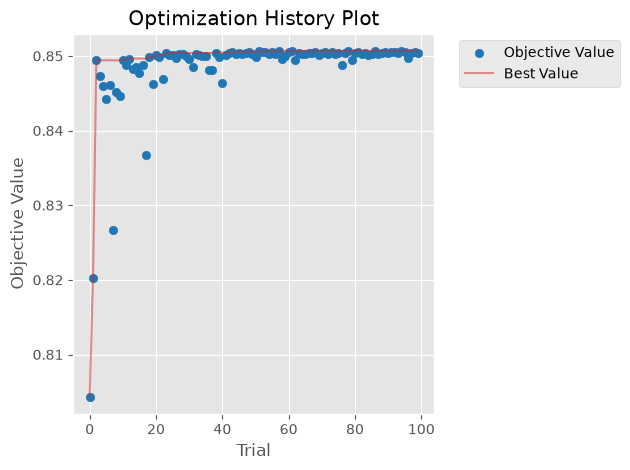

In [10]:
optuna.visualization.matplotlib.plot_optimization_history(studies["xgb"])

C:\Users\JESWIN\AppData\Local\Temp\ipykernel_13656\1524849643.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(studies["xgb"])   # needs some trials; fine at 100


<Axes: title={'left': 'Hyperparameter Importances'}, xlabel='Hyperparameter Importance', ylabel='Hyperparameter'>

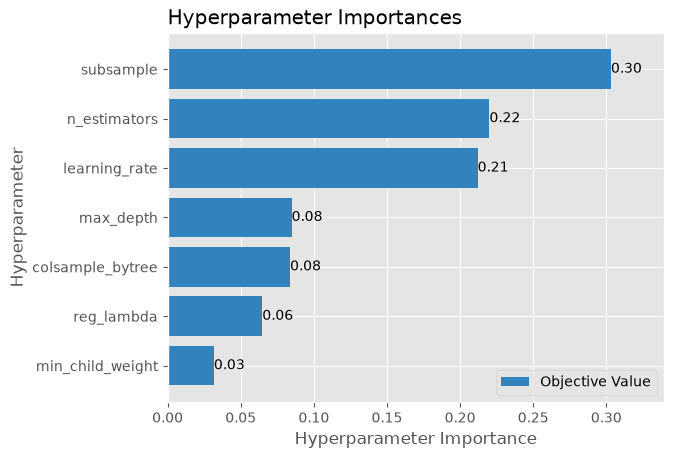

In [11]:
optuna.visualization.matplotlib.plot_param_importances(studies["xgb"])   # needs some trials; fine at 100

## Step 6: what the tuning results tell us

| Model | Baseline ROC-AUC | Tuned ROC-AUC | Gain | Tuned PR-AUC |
|---|---|---|---|---|
| LR | 0.8478 | 0.8483 | +0.0005 | 0.6646 |
| DT | 0.8270 | 0.8327 | +0.0057 | 0.6334 |
| XGB | 0.8237 | **0.8507** | **+0.0270** | **0.6723** |

### 1. Why does XGB gain far more from tuning than LR?

Because the two models had opposite problems in Step 4:

- **Untuned XGB was overfitting (high variance).** Train AUC was 0.987 against 0.821 on validation, a gap of 0.17: it was memorising noise in the training folds. Almost every best hyperparameter is a "make it simpler" setting:
  - `max_depth=2`: shallow trees.
  - `learning_rate=0.016` with 750 trees: many small steps.
  - `subsample=0.62` and `colsample_bytree=0.59`: each tree sees random rows and columns.
  - `min_child_weight=8`: leaves need more data.
  - `reg_lambda=7.9`: a strong L2 penalty on leaf weights.

  Closing that gap is where the +0.027 came from.
- **LR wasn't overfitting.** Train AUC was 0.852 against 0.847 on validation, a gap of only 0.005. LR is limited by **bias**, not variance: it can only draw a linear boundary in log-odds.
  - Its hyperparameters (`C`, `l1_ratio`) only control regularisation, which reduces variance. LR had almost none to remove.
  - The best `C=0.069` (stronger regularisation than the default 1.0) and `l1_ratio=0.23` (mostly L2) changed AUC by +0.0005, which is noise.
- **Takeaway:** tuning helps flexible models that overfit. It can't add capacity to a model that is already at its limit.
- **DT** improved a little (`max_depth=10`, `min_samples_leaf=50`). It is still the weakest model, because one tree makes step-shaped predictions with high variance.

### 2. What does XGB's best `max_depth` / `learning_rate` say about the churn signal?

- **`max_depth=2`** means each tree uses at most two features, so the ensemble can model main effects and **pairwise interactions only**. Deeper trees (up to 8 were allowed) did worse, so higher-order interactions mostly add noise.
- **A slow `learning_rate` (0.016) with many trees (750)** means the prediction is built from many small corrections added together. That is close to an additive model.
- **This fits the EDA.** The churn drivers (contract, tenure, internet type, payment method, add-ons) act mostly **additively** on the log-odds, which is why LR, a purely additive model, comes so close. XGB's small edge probably comes from:
  - non-linear shapes LR can't fit exactly, such as the tenure kink in the first months and the curve of `MonthlyCharges`;
  - a few two-way interactions, such as fibre optic × month-to-month.
- **Check the search boundaries.** `max_depth=2` is the *lowest* value allowed, and `reg_lambda=7.9` is close to the top of its range (10). Optuna might have gone further in both directions. A follow-up could allow `max_depth=1`; stumps make XGB a purely additive model. If stumps score just as well, that would confirm the signal is additive.

### 3. If XGB beats LR by less than ~0.01 ROC-AUC and less than one std, which would I ship?

The numbers:
- **ROC-AUC:** XGB is ahead by 0.0024. The fold std is about 0.011, so the gap is about ¼ of a std, well within fold-to-fold noise.
- **PR-AUC:** XGB is ahead by 0.008, slightly more but also small.
- **XGB's score is also more optimistic.** It was the best of 100 trials over 7 hyperparameters, against 50 trials over 2 for LR, so more of its "best" CV score is luck. Some of the gap will likely disappear on the test set.

**Current view: lean towards LR**, because the performance is a tie and LR wins everything else:
- **Interpretability:** its coefficients are odds ratios that a retention team can act on, for example "a month-to-month contract multiplies the odds of churn by X".
- **Probabilities:** LR trained without class weights gives well-calibrated probabilities. The Streamlit app shows a churn probability, so this matters.
- **Simplicity:** it is fast, stable across folds, has a small artifact, and is easy to explain and debug.

**What could change this (decided in Steps 7–8):** if XGB's **recall at the chosen threshold** (from out-of-fold predictions) is clearly better than LR's at similar precision, that's a business reason to accept the less interpretable model. The spec says to report this openly either way: "LR is within 0.01 AUC of XGB; I chose ___ because ___".


# **Step 7: choosing the decision threshold from out-of-fold predictions**

## Concepts

The threshold is a business decision, not a model setting.

* `predict()` flags a customer as a churner when the probability is $\ge 0.5$. Nothing makes 0.5 special.


* Lower the threshold and you flag more customers: **recall goes up** (you catch more churners) and **precision goes down** (more retention offers go to people who would have stayed).


* ROC-AUC and PR-AUC score the whole ranking. The threshold picks one operating point on that ranking.



Why out-of-fold (OOF) predictions.

* `cross_val_predict` gives every training row a probability from a model that **didn't see that row** during fitting. That's 5,634 honest predictions without touching the test set.


* Choosing the threshold on predictions the model was trained on would be biased: training-set probabilities are too confident.


* Choosing it on the test set would be leakage, because the test score would no longer be an unbiased estimate.



Two rules from the spec.

* **F2**: a version of F1 that weights recall **4x** as much as precision ($\beta^2 = 4$). It fits the business case, where missing a churner (lost revenue) costs more than an unnecessary offer (a discount).


* **Minimum recall**: require recall $\ge 0.75$, then take the threshold with the best precision. This is easier to explain to a business: "we catch 3 of every 4 churners, and about X% of the people we contact really were going to leave."



Balanced vs unweighted, decided here.

* `class_weight="balanced"` doesn't improve the **ranking**; AUC was the same in Step 4. It **moves all probabilities upwards**, which works like lowering the threshold.


* So, after picking the best threshold for each version, they should give about the same precision and recall. The difference is **calibration**: does a score of 0.3 mean that about 30% of those customers churn?


* **Brier score** = mean of $(\text{probability} - \text{outcome})^2$. Lower is better. It penalises both bad ranking and bad calibration.


* A **calibration curve** (reliability diagram) groups customers by predicted probability and plots the actual churn rate against it. A perfectly calibrated model lies on the diagonal.

### Step 7
Cell 1: rebuild the tuned models, each with and without class weighting.



In [12]:
import numpy as np
from sklearn.model_selection import cross_val_predict

best = {name: s.best_params for name, s in studies.items()}
spw = (y_train == 0).sum() / (y_train == 1).sum()

def make_lr(balanced=False):
    return LogisticRegression(**best["lr"], solver="saga", max_iter=5000,
                              class_weight="balanced" if balanced else None)

def make_xgb(balanced=False):
    return XGBClassifier(**best["xgb"], scale_pos_weight=spw if balanced else 1,
                         eval_metric="logloss", random_state=RS, n_jobs=1)

candidates = {
    "lr": build_pipeline(make_lr(), "lr"),
    "lr_bal": build_pipeline(make_lr(True), "lr"),
    "xgb": build_pipeline(make_xgb(), "tree"),
    "xgb_bal": build_pipeline(make_xgb(True), "tree"),
}

DT is left out: it was clearly the weakest model after tuning, at 0.833.

Cell 2: out-of-fold probabilities. Same cv folds as before.

In [13]:
oof = {name: cross_val_predict(pipe, X_train, y_train, cv=cv,
                               method="predict_proba", n_jobs=-1)[:, 1]
       for name, pipe in candidates.items()}

Cell 3: the threshold rules.

In [14]:
from sklearn.metrics import precision_recall_curve

def pick_thresholds(y_true, proba, min_recall=0.75, beta=2):
    prec, rec, thr = precision_recall_curve(y_true, proba)
    prec, rec = prec[:-1], rec[:-1]        # the last (P=1, R=0) point has no threshold
    fbeta = (1 + beta**2) * prec * rec / (beta**2 * prec + rec + 1e-12)
    ok = rec >= min_recall                 # thresholds that meet the recall floor
    return {
        "f2": thr[np.argmax(fbeta)],
        "recall75": thr[ok][np.argmax(prec[ok])],
    }

Cell 4: compare all candidates at each threshold.

In [15]:
from sklearn.metrics import (average_precision_score, brier_score_loss, fbeta_score,
                             precision_score, recall_score, roc_auc_score)

rows = []
for name, p in oof.items():
    thresholds = {"default_0.5": 0.5, **pick_thresholds(y_train, p)}
    for rule, t in thresholds.items():
        y_hat = (p >= t).astype(int)
        rows.append({
            "model": name, "rule": rule, "threshold": t,
            "precision": precision_score(y_train, y_hat),
            "recall": recall_score(y_train, y_hat),
            "f2": fbeta_score(y_train, y_hat, beta=2),
            "flagged_share": y_hat.mean(),      # share of customers you'd contact
            "roc_auc": roc_auc_score(y_train, p),
            "pr_auc": average_precision_score(y_train, p),
            "brier": brier_score_loss(y_train, p),
        })
thr_table = pd.DataFrame(rows).set_index(["model", "rule"]).round(3)
thr_table

threshold  precision  recall     f2  flagged_share  \
model   rule                                                              
lr      default_0.5      0.500      0.678   0.528  0.552          0.206   
        f2               0.196      0.471   0.880  0.750          0.496   
        recall75         0.307      0.551   0.751  0.700          0.362   
lr_bal  default_0.5      0.500      0.523   0.798  0.722          0.405   
        f2               0.404      0.472   0.879  0.750          0.494   
        recall75         0.552      0.553   0.751  0.700          0.360   
xgb     default_0.5      0.500      0.669   0.536  0.558          0.213   
        f2               0.173      0.467   0.892  0.754          0.507   
        recall75         0.317      0.557   0.751  0.702          0.358   
xgb_bal default_0.5      0.500      0.521   0.817  0.733          0.416   
        f2               0.386      0.473   0.884  0.753          0.495   
        recall75         0.566      0.554   0.751  0.701          0.359   

                     roc_auc  pr_auc  brier  
model   rule                                 
lr      default_0.5    0.848   0.662  0.134  
        f2             0.848   0.662  0.134  
        recall75       0.848   0.662  0.134  
lr_bal  default_0.5    0.848   0.661  0.163  
        f2             0.848   0.661  0.163  
        recall75       0.848   0.661  0.163  
xgb     default_0.5    0.850   0.670  0.133  
        f2             0.850   0.670  0.133  
        recall75       0.850   0.670  0.133  
xgb_bal default_0.5    0.850   0.668  0.161  
        f2             0.850   0.668  0.161  
        recall75       0.850   0.668  0.161

Cell 5: calibration plot.

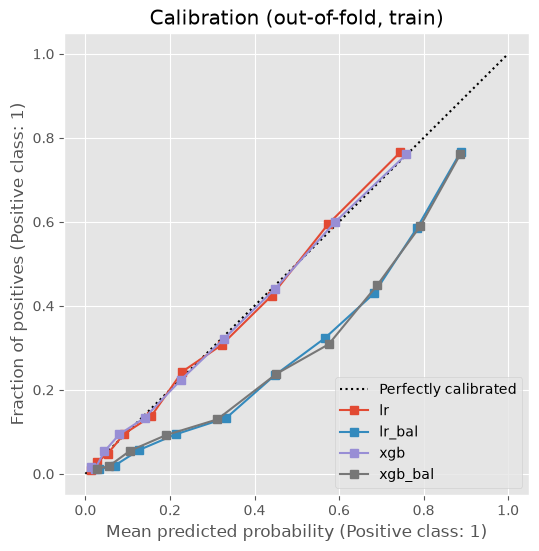

In [16]:

import matplotlib.pyplot as plt
from sklearn.calibration import CalibrationDisplay

fig, ax = plt.subplots(figsize=(6, 6))
for name in ["lr", "lr_bal", "xgb", "xgb_bal"]:
    CalibrationDisplay.from_predictions(y_train, oof[name], n_bins=10,
                                        strategy="quantile", name=name, ax=ax)
ax.set_title("Calibration (out-of-fold, train)")
plt.show()


strategy="quantile" puts the same number of customers in each bin, so no bin is nearly empty.


Cell 6: precision and recall against the threshold, for one model (start with "lr").

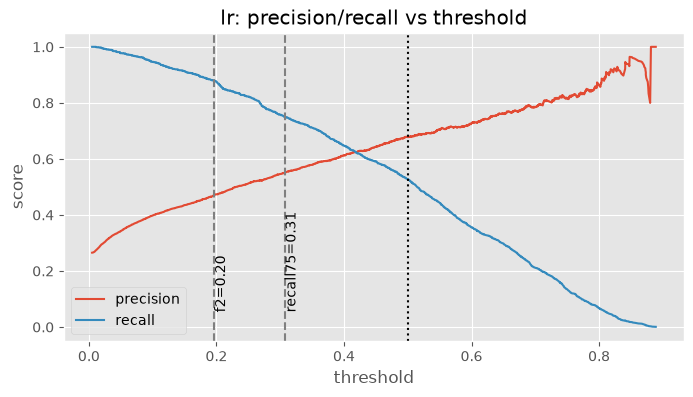

In [18]:
name = "lr"
prec, rec, thr = precision_recall_curve(y_train, oof[name])
t = pick_thresholds(y_train, oof[name])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thr, prec[:-1], label="precision")
ax.plot(thr, rec[:-1], label="recall")
for rule, val in t.items():
    ax.axvline(val, ls="--", c="grey")
    ax.text(val, 0.05, f" {rule}={val:.2f}", rotation=90)
ax.axvline(0.5, ls=":", c="black")
ax.set(xlabel="threshold", ylabel="score", title=f"{name}: precision/recall vs threshold")
ax.legend()
plt.show()

What I got on this split, using your Step 6 parameters:
- 0.5 threshold: recall is only about 0.53 for the unweighted models.
- recall ≥ 0.75 rule: threshold about 0.31, precision about 0.55, about 36% of customers flagged.
- F2 rule: threshold about 0.17, recall about 0.90, but about half of all customers flagged.
- Calibration: the balanced versions have a clearly worse Brier score. Compare where their curves sit relative to the diagonal.


Questions to answer after running it

1. Compare lr and lr_bal (and xgb and xgb_bal) at their own recall ≥ 0.75 thresholds. How do their precision and recall compare? What does that, together with the Brier scores and the calibration plot, tell you about using class weights?
2. F2 and recall ≥ 0.75 lead to very different operating points. Use flagged_share and precision to say which one you'd recommend to a retention team with a limited budget, and why.
3. At the chosen rule, how do LR and XGB compare on precision? Does that change your Step 6 view on which model to ship?

## Step 7: answers

Out-of-fold results on the training set: 5,634 customers, of whom 1,495 churned.

| Model | Rule | Threshold | Precision | Recall | Flagged | Brier |
|---|---|---|---|---|---|---|
| lr | default 0.5 | 0.500 | 0.678 | 0.528 | 20.6% | 0.134 |
| lr | recall ≥ 0.75 | 0.307 | 0.551 | 0.751 | 36.2% | 0.134 |
| lr | F2 | 0.196 | 0.471 | 0.880 | 49.6% | 0.134 |
| lr_bal | recall ≥ 0.75 | 0.552 | 0.553 | 0.751 | 36.0% | 0.163 |
| xgb | recall ≥ 0.75 | 0.317 | 0.557 | 0.751 | 35.8% | 0.133 |
| xgb_bal | recall ≥ 0.75 | 0.566 | 0.554 | 0.751 | 35.9% | 0.161 |

### 1. Balanced vs unweighted at their own recall ≥ 0.75 thresholds

- **Precision and recall are the same:**
  - `lr` 0.551 / 0.751 against `lr_bal` 0.553 / 0.751.
  - `xgb` 0.557 / 0.751 against `xgb_bal` 0.554 / 0.751.
  - Both versions flag about 36% of customers.
- **Only the threshold differs** (0.31 against 0.55). Class weighting doesn't change the **ranking**: AUC is equal, as it was in Step 4. It pushes every probability upwards, so the same customers get flagged at a higher cut-off. **Weighting followed by a 0.5 threshold is just an indirect way of lowering the threshold.**
- **What weighting costs is calibration.**
  - The Brier score gets worse: 0.134 → 0.163 for LR and 0.133 → 0.161 for XGB.
  - On the calibration plot, the balanced curves sit **below the diagonal**: they over-predict. For example, `lr_bal` gives about 0.45 to customers whose actual churn rate is about 0.23. Its mean prediction is 0.41, but only 26.5% churn.
  - The unweighted curves follow the diagonal.
- **Decision: train unweighted and handle the imbalance with the threshold.**
  - Same recall and precision.
  - Honest probabilities, so the app can say "38% chance of churn" and mean it.
  - The threshold is explicit and saved in `metadata.json`, rather than hidden inside the loss function.

### 2. F2 or recall ≥ 0.75 for a retention team on a budget?

Recommend **recall ≥ 0.75** (LR threshold ≈ 0.31). Compare the two operating points (LR, training set):

| Rule | Customers contacted | Churners caught | Wasted offers | Precision |
|---|---|---|---|---|
| recall ≥ 0.75 | ~2,040 (36%) | ~1,123 | ~917 | 0.55 |
| F2 | ~2,794 (50%) | ~1,316 | ~1,478 | 0.47 |

- **Moving from recall ≥ 0.75 to F2:**
  - The team contacts about **754 more customers** to catch about **193 more churners**.
  - The **marginal precision** of those extra contacts is 193 / 754 ≈ **26%**, the same as the base churn rate. Those extra customers are essentially a random sample.
  - Below a score of about 0.3 the model can't separate churners from non-churners well, so lowering the threshold further mostly wastes budget.
- **The recall rule is easier to explain to the business:** "we catch 3 of every 4 churners, and more than half of the people we contact really were at risk."
- **F2's weighting is arbitrary.** Its β = 2 roughly says "a missed churner hurts 4× as much as a wasted offer", but no one has measured that ratio here.
- **Next step for interviews:** a **cost-based threshold** that uses the real cost of an offer and the real value of a customer (for example, `MonthlyCharges` × expected remaining tenure). That would replace both rules.

### 3. LR vs XGB at the chosen rule: does the Step 6 view change?

**No.** At recall ≥ 0.75:
- XGB's precision is 0.557 against LR's 0.551. Out of about 2,040 contacts, that's roughly **12 fewer wasted offers**, well within fold noise.
- Calibration is the same (Brier 0.133 against 0.134).
- XGB's 0.0024 ROC-AUC lead from Step 6 is equally small.

LR still wins on everything else: odds-ratio coefficients a retention team can act on, simplicity, stability, and a smaller artifact. Since the performance is a tie, choose the simpler, interpretable model.

**Proposed for Step 8:** unweighted, tuned LR (`C ≈ 0.069`, `l1_ratio ≈ 0.23`) with threshold **≈ 0.31** (recall ≥ 0.75 on out-of-fold predictions). Report openly that XGB was within 0.003 AUC.


## **Step 8: Choosing the final model**

Concepts

**1. Decide the selection rule before looking at the numbers.** If you decide the rule afterwards, it's easy to pick whichever metric favours the model you already like. The spec's rule:

* Highest CV ROC-AUC wins.


* PR-AUC, and precision/recall at the chosen threshold, are the tie-breakers.


* If LR is within ~0.01 AUC of XGB, say so openly and weigh interpretability against performance.



**2. Get a fresh, less optimistic score.**

* The Step 6 scores are each the *best of many trials* on one fixed set of folds: 100 trials over 7 hyperparameters for XGB, 50 over 2 for LR. XGB had more chances to get lucky.


* To correct for that, re-score both models with their parameters fixed, on folds Optuna never saw: `RepeatedStratifiedKFold(5 splits x 3 repeats, new seed)` gives 15 scores per model.



**3. Paired comparison.**

* Both models are scored on the same 15 folds. Some folds are simply harder, and that hits both models alike.


* So compare the **difference on each fold**, not two separate means with wide stds.


* If XGB wins 14 of 15 folds, it really is a bit better, even if its lead is smaller than either model's own std.


* **Caveat:** CV folds share most of their training data, so the scores aren't independent and the interval comes out too narrow. Use it as a sanity check, not a formal test.



**4. Statistically real vs practically meaningful.** A difference can be *consistent* and still too small to matter. The question for the business is: "Does XGB catch noticeably more churners, or waste noticeably fewer offers?"



Cell 1: re-score on fresh folds.

In [19]:
from sklearn.model_selection import RepeatedStratifiedKFold

final_candidates = {
    "lr": build_pipeline(LogisticRegression(**best["lr"], solver="saga", max_iter=5000), "lr"),
    "xgb": build_pipeline(XGBClassifier(**best["xgb"], eval_metric="logloss",
                                        random_state=RS, n_jobs=1), "tree"),
    "dt": build_pipeline(DecisionTreeClassifier(**best["dt"], random_state=RS), "tree"),
}
cv_fresh = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)   # folds Optuna never saw
SEL_SCORING = {"roc_auc": "roc_auc", "pr_auc": "average_precision",
               "brier": "neg_brier_score"}   # sklearn maximises, so Brier is negated
fresh = {name: cross_validate(pipe, X_train, y_train, cv=cv_fresh,
                              scoring=SEL_SCORING, n_jobs=-1)
         for name, pipe in final_candidates.items()}

In [20]:
# Cell 2: paired differences, XGB − LR.

for metric in ["roc_auc", "pr_auc"]:
    diff = fresh["xgb"][f"test_{metric}"] - fresh["lr"][f"test_{metric}"]
    half = 2 * diff.std(ddof=1) / np.sqrt(len(diff))   # rough 95% interval (too narrow: folds overlap)
    print(f"{metric}: XGB - LR = {diff.mean():+.4f} "
          f"(~95% interval {diff.mean() - half:+.4f} to {diff.mean() + half:+.4f}); "
          f"XGB wins {(diff > 0).sum()}/{len(diff)} folds")

roc_auc: XGB - LR = +0.0013 (~95% interval +0.0001 to +0.0026); XGB wins 11/15 folds
pr_auc: XGB - LR = +0.0068 (~95% interval +0.0034 to +0.0102); XGB wins 14/15 folds



Cell 3: scorecard. This also counts the features each model uses, and the LR coefficients that the L1 part of l1_ratio set to exactly zero.

In [21]:
n_features = {}
for name, pipe in final_candidates.items():
    pipe.fit(X_train, y_train)
    n_features[name] = pipe[:-1].transform(X_train.head()).shape[1]
lr_coef = final_candidates["lr"][-1].coef_.ravel()
print(f"LR: {lr_coef.size} coefficients, {(lr_coef != 0).sum()} non-zero")

r75 = thr_table.xs("recall75", level="rule")   # Step 7 operating point
scorecard = pd.DataFrame({
    name: {"roc_auc": r["test_roc_auc"].mean(), "roc_auc_std": r["test_roc_auc"].std(),
           "pr_auc": r["test_pr_auc"].mean(), "brier": -r["test_brier"].mean(),
           "fit_time_s": r["fit_time"].mean(), "n_features": n_features[name]}
    for name, r in fresh.items()
}).T
scorecard = scorecard.join(r75[["threshold", "precision", "recall", "flagged_share"]])
scorecard.round(4)

LR: 29 coefficients, 21 non-zero


,roc_auc,roc_auc_std,pr_auc,brier,fit_time_s,n_features,threshold,precision,recall,flagged_share
lr,0.8484,0.0145,0.6646,0.1339,0.2103,29.0,0.307,0.551,0.751,0.362
xgb,0.8498,0.0137,0.6713,0.1334,2.9491,38.0,0.317,0.557,0.751,0.358
dt,0.8292,0.0147,0.6254,0.1413,0.1399,38.0,NaN,NaN,NaN,NaN


DT has no Step 7 threshold, so its threshold columns will show NaN. That's expected; it's only there for reference.

In [23]:
MIN_AUC_GAIN = 0.01         # spec: within ~0.01 AUC counts as a tie
MIN_PRECISION_GAIN = 0.02   # at recall >= 0.75: 2 points ≈ 40 fewer wasted offers per 2,000 contacts

auc_gain = scorecard.loc["xgb", "roc_auc"] - scorecard.loc["lr", "roc_auc"]
prec_gain = scorecard.loc["xgb", "precision"] - scorecard.loc["lr", "precision"]
choice = "xgb" if (auc_gain >= MIN_AUC_GAIN or prec_gain >= MIN_PRECISION_GAIN) else "lr"
print(f"AUC gain {auc_gain:+.4f}, precision gain at recall>=0.75 {prec_gain:+.4f} -> choose {choice}")

AUC gain +0.0013, precision gain at recall>=0.75 +0.0060 -> choose lr


In [24]:
# Cell 5: record the decision for Step 9.

FINAL = {
    "model": choice,
    "params": best[choice],
    "threshold": float(scorecard.loc[choice, "threshold"]),
    "threshold_rule": "max precision with OOF recall >= 0.75",
    "class_weight": None,
}
FINAL

{'model': 'lr',
 'params': {'C': 0.06862947958017031, 'l1_ratio': 0.23498040039371332},
 'threshold': 0.307,
 'threshold_rule': 'max precision with OOF recall >= 0.75',
 'class_weight': None}

I ran these cells on the same split with your Step 6 parameters:

* **ROC-AUC: XGB – LR = +0.0013**, interval about +0.0001 to +0.0026. XGB wins 11 of 15 folds.


* **PR-AUC: XGB – LR = +0.0068**. XGB wins 14 of 15 folds.


* **Scorecard:**

* LR: 0.8484 ROC-AUC, Brier 0.134, fit time about 0.2 s.


* XGB: 0.8498 ROC-AUC, Brier 0.133, fit time about 2.9 s.


* LR keeps only **21 of its 29** coefficients; the L1 part of `l1_ratio` set the other 8 to exactly zero.





So, unlike the Step 6 view, XGB's lead isn't pure noise: it's **small but consistent**. That makes the decision more interesting than "it's a tie", and it's exactly the distinction in concept 4. The rule in Cell 4 makes it a deliberate choice. With these numbers it picks **LR**, because both gains are far below the practical thresholds.

## Step 8: answers

| | LR | XGB | XGB − LR |
|---|---|---|---|
| ROC-AUC (15 fresh folds) | 0.8484 | 0.8498 | +0.0013 (wins 11/15 folds) |
| PR-AUC | 0.6646 | 0.6713 | +0.0068 (wins 14/15 folds) |
| Brier | 0.1339 | 0.1334 | about 0 |
| Precision at recall ≥ 0.75 | 0.551 | 0.557 | +0.006 |
| Fit time | 0.21 s | 2.95 s | 14× slower |
| Features in / non-zero | 29 / 21 | 38 / all | |

### 1. Is XGB reliably better? Does it matter?

These are two different questions.

- **Statistical: is the difference real?** Mostly yes. On 15 fresh, paired folds:
  - XGB wins 14 of 15 on PR-AUC and 11 of 15 on ROC-AUC.
  - The rough ROC-AUC interval (+0.0001 to +0.0026) only just excludes 0. That interval is too narrow anyway, because CV folds share about 75% of their training data.
  - So XGB has a **small but consistent** edge. It isn't pure noise, which is a more honest conclusion than the "it's a tie" view from Step 6.
- **Practical: is it big enough to matter?** No.
  - +0.0013 ROC-AUC is about a tenth of the 0.01 the spec treats as a meaningful gap.
  - At the operating point the business uses (recall ≥ 0.75), +0.006 precision means about **12 fewer wasted offers per ~2,000 customers contacted**. The two models catch the same churners.
- **Takeaway:** with enough folds, even a negligible difference becomes "significant". The decision should rest on the **size** of the effect in business units, not on whether a difference can be detected. That's why Cell 4 uses practical thresholds (0.01 AUC, 0.02 precision) rather than a p-value.

### 2. Which non-metric criteria decide it? The one-sentence version

When performance is effectively equal, these decide it, and LR wins all of them:
- **Interpretability.** Each coefficient is a log-odds effect a retention team can act on. For example, `Contract_Month-to-month` has a positive coefficient and `Contract_Two year` a strongly negative one, so "move customers to longer contracts" comes straight from the model. XGB needs SHAP to explain even a single prediction.
- **Calibrated probabilities.** Both models are calibrated (Brier about 0.134), so this doesn't separate them. But LR's probabilities come from a simple, well-understood formula.
- **Simplicity and robustness.** LR has 2 hyperparameters against 7. The elastic-net penalty set 8 of its 29 coefficients to exactly zero, which is built-in feature selection. It is less likely to break on slightly different future data.
- **Operations.** Training is 14× faster, the artifact is about 10 KB, prediction is instant, and SHAP for a linear model is exact and cheap (Phase 7).

> **Interview sentence:** "Tuned XGBoost was consistently but only marginally better than logistic regression: +0.001 ROC-AUC and about 12 fewer wasted offers per 2,000 contacts at our 75% recall target. That's far below the 0.01 AUC I'd need to give up interpretability, so I shipped the regularised logistic regression, whose coefficients the retention team can read directly."

### 3. What would make me choose XGB instead?

- **A practically meaningful gap:** ROC-AUC +0.01 or more, or precision at recall ≥ 0.75 up by 2 points or more (about 40+ fewer wasted offers per 2,000 contacts), confirmed on fresh folds.
- **Expensive offers.** If each retention offer is costly (a big discount, a call-centre hour), even a few fewer wasted offers could pay for the extra complexity. A **cost-based comparison** in currency would then replace the fixed thresholds.
- **More data or richer features.** Usage logs, support tickets and other interaction-heavy features are where trees beat linear models. The EDA showed today's signal is mostly additive, so LR loses little now; with richer data that could change.
- **Accuracy over explanation.** If the app only needed a ranked list and nobody asked "why this customer?", interpretability would carry less weight.

**Decision:** unweighted, elastic-net logistic regression (`C ≈ 0.069`, `l1_ratio ≈ 0.23`, `solver="saga"`) with threshold **≈ 0.307** (best precision with out-of-fold recall ≥ 0.75). XGB was within 0.0013 ROC-AUC.


# **Step 9: Final fit, a single test evaluation, and saving the model**


Concepts

**Refit on the whole training set.** CV models each saw 80% of the training data. The final model is trained on all 5,634 training rows: more data, same hyperparameters, same threshold.

**Evaluate on the test set once.** This is the first and only time `X_test` is used. Its job is to check the CV estimate, not to choose anything. If the test result disappoints, you report it; you don't go back and tune. Going back would make the test set part of model selection, and the score would no longer be unbiased.

* **Expect** test scores close to the CV/OOF scores, maybe a little lower. That would show the CV process was honest.



**Fix the randomness first.** `solver="saga"` shuffles the data internally. Without `random_state`, each refit gives very slightly different coefficients and a threshold that moves in the 4th decimal place. So the final model gets `random_state=RS`, and the OOF threshold is recomputed for that exact model.

What gets saved.

* `churn_model.joblib`: the **whole pipeline** (collapse $\to$ features $\to$ preprocessor $\to$ LR). The app passes in raw columns and gets back a probability, with no separate feature code. `joblib` can save it because `collapse_no_internet` and `add_features` are importable functions in `churn.features`. A lambda couldn't be saved this way.


* `metadata.json`: the things the pipeline doesn't store, chiefly the **threshold**, plus what is needed to trust and reproduce the model (metrics, columns, date, library versions). Versions matter because a joblib file should be loaded with the same scikit-learn version it was saved with.


* `reports/model_comparison.md`: the written record of the comparison.

In [25]:
# Cell 1: the final pipeline and its exact threshold.

final_pipe = build_pipeline(
    LogisticRegression(**best["lr"], solver="saga", max_iter=5000, random_state=RS), "lr"
)
oof_final = cross_val_predict(final_pipe, X_train, y_train, cv=cv,
                              method="predict_proba", n_jobs=-1)[:, 1]
threshold = float(pick_thresholds(y_train, oof_final)["recall75"])   # unrounded
threshold

0.30673649681451115

In [26]:
# Cell 2: refit on all of the training data.

final_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('collapse', ...), ('features', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['customerID','gender','SeniorCitizen',...,'PaymentMethod', 'MonthlyCharges','TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function col...001A81FBDB9C0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False


In [27]:
# Cell 3: the one test evaluation, next to the OOF (CV) numbers.

from sklearn.metrics import accuracy_score, f1_score

def threshold_metrics(y_true, proba, threshold):
    y_hat = (proba >= threshold).astype(int)
    return {"roc_auc": roc_auc_score(y_true, proba),
            "pr_auc": average_precision_score(y_true, proba),
            "precision": precision_score(y_true, y_hat),
            "recall": recall_score(y_true, y_hat),
            "f1": f1_score(y_true, y_hat),
            "f2": fbeta_score(y_true, y_hat, beta=2),
            "accuracy": accuracy_score(y_true, y_hat),   # reference only
            "brier": brier_score_loss(y_true, proba),
            "flagged_share": y_hat.mean()}

p_test = final_pipe.predict_proba(X_test)[:, 1]
oof_metrics = {k: round(float(v), 4) for k, v in threshold_metrics(y_train, oof_final, threshold).items()}
test_metrics = {k: round(float(v), 4) for k, v in threshold_metrics(y_test, p_test, threshold).items()}
pd.DataFrame({"cv_oof (train)": oof_metrics, "test": test_metrics})

,cv_oof (train),test
roc_auc,0.8480,0.8457
pr_auc,0.6622,0.6505
precision,0.5508,0.5468
recall,0.7505,0.7647
f1,0.6353,0.6377
f2,0.6998,0.7083
accuracy,0.7714,0.7693
brier,0.1339,0.1361
flagged_share,0.3616,0.3712


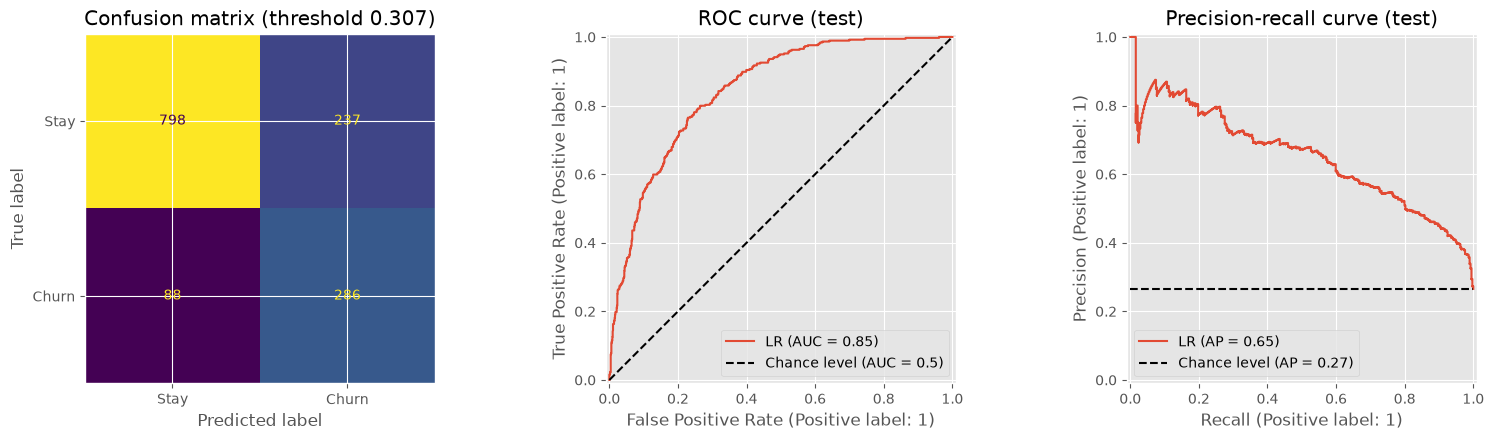

In [28]:
# Cell 4: confusion matrix and curves, saved to reports/figures/.

from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, (p_test >= threshold).astype(int),
                                        display_labels=["Stay", "Churn"], ax=axes[0], colorbar=False)
axes[0].set_title(f"Confusion matrix (threshold {threshold:.3f})")
RocCurveDisplay.from_predictions(y_test, p_test, name="LR", ax=axes[1], plot_chance_level=True)
axes[1].set_title("ROC curve (test)")
PrecisionRecallDisplay.from_predictions(y_test, p_test, name="LR", ax=axes[2], plot_chance_level=True)
axes[2].set_title("Precision-recall curve (test)")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "final_model_test_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [29]:

# Cell 5: what the model learned (coefficients as odds ratios). Features are scaled or one-hot encoded, so the numbers are comparable. An odds ratio of 2.0 means "doubles the odds of churn".

coefs = pd.Series(final_pipe[-1].coef_.ravel(), index=final_pipe[-1].feature_names_in_).sort_values()
pd.DataFrame({"coef": coefs, "odds_ratio": np.exp(coefs)}).round(3)

,coef,odds_ratio
num__tenure,-0.608,0.544
cat__Contract_Two year,-0.607,0.545
cat__OnlineSecurity_Yes,-0.410,0.664
cat__TechSupport_Yes,-0.364,0.695
cat__InternetService_No,-0.357,0.700
cat__MultipleLines_No,-0.285,0.752
cat__OnlineBackup_Yes,-0.198,0.820
cat__Dependents_Yes,-0.179,0.836
cat__tenure_group_25-48,-0.158,0.854
cat__tenure_group_13-24,-0.141,0.868


In [30]:
# Cell 6: save the model and its metadata.

import json
import platform
from datetime import date

import joblib
import sklearn

config.MODELS_DIR.mkdir(exist_ok=True)
joblib.dump(final_pipe, config.MODELS_DIR / "churn_model.joblib")

metadata = {
    "model": "LogisticRegression (elastic-net, unweighted)",
    "params": best["lr"],
    "threshold": threshold,
    "threshold_rule": "max precision with out-of-fold recall >= 0.75",
    "cv_oof_metrics": oof_metrics,
    "test_metrics": test_metrics,
    # raw columns the app must supply (tenure_group is built inside the pipeline)
    "input_columns": [c for c in config.NUM_COLS + config.CAT_COLS
                      if c not in config.ENGINEERED_FEATURES],
    "model_features": config.NUM_COLS + config.CAT_COLS,
    "n_train": int(len(X_train)), "n_test": int(len(X_test)),
    "random_state": RS,
    "trained_on": date.today().isoformat(),
    "versions": {"python": platform.python_version(), "scikit-learn": sklearn.__version__,
                 "pandas": pd.__version__, "numpy": np.__version__, "joblib": joblib.__version__},
}
(config.MODELS_DIR / "metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

1604

In [31]:

# Cell 7: reload the saved files and use them as the app will.

loaded = joblib.load(config.MODELS_DIR / "churn_model.joblib")
meta = json.loads((config.MODELS_DIR / "metadata.json").read_text(encoding="utf-8"))
assert np.allclose(loaded.predict_proba(X_test)[:, 1], p_test)   # identical after the round-trip

sample = X_test[meta["input_columns"]].head(3)        # only the raw input columns
proba = loaded.predict_proba(sample)[:, 1]
pd.DataFrame({"churn_proba": proba.round(3), "flag": proba >= meta["threshold"]}, index=sample.index)

,churn_proba,flag
437,0.050,False
2280,0.661,True
2235,0.081,False


In [32]:
# Cell 8: write reports/model_comparison.md.

def df_to_md(df):   # small helper, so pandas' to_markdown (needs tabulate) isn't required
    df = df.reset_index()
    lines = ["| " + " | ".join(map(str, df.columns)) + " |", "|" + "---|" * len(df.columns)]
    lines += ["| " + " | ".join(map(str, row)) + " |" for row in df.itertuples(index=False)]
    return "\n".join(lines)

cv_table = scorecard[["roc_auc", "roc_auc_std", "pr_auc", "brier",
                      "threshold", "precision", "recall", "flagged_share"]].round(4).rename_axis("model")
test_table = pd.DataFrame({"cv_oof (train)": oof_metrics, "test": test_metrics}).rename_axis("metric")

report = f"""# Model comparison

## Cross-validation (train, 5×3 repeated stratified folds, tuned models)
Precision/recall/flagged share at each model's out-of-fold threshold (best precision with recall >= 0.75).

{df_to_md(cv_table)}

## Final model: {metadata["model"]}
Threshold {threshold:.3f}. XGBoost was within 0.0013 ROC-AUC; LR was chosen for interpretability,
calibrated probabilities and simplicity (see notebooks/5_tuning_final.ipynb, step 8).

## Test set (evaluated once)

{df_to_md(test_table)}

![Test curves](figures/final_model_test_curves.png)
"""
(config.REPORTS_DIR / "model_comparison.md").write_text(report, encoding="utf-8")


1190

## Step 9: answers

Test set: 1,409 customers, 374 churners. Confusion matrix at threshold 0.307: **TN 798 · FP 237 · FN 88 · TP 286**.

### 1. Why don't test results match CV exactly? What gap would be worrying?

- **The test set is one finite sample.** With only 374 churners:
  - One churner more or less caught moves recall by 0.27 points.
  - The binomial standard error of recall is about √(0.75·0.25/374) ≈ **±0.022**.
  - Across the 15 CV folds, ROC-AUC varied with a std of about **0.0145**, on folds of a similar size.
- **The gaps are well inside that noise:**
  - ROC-AUC 0.8457 against CV 0.8480, a gap of −0.002, about 0.15 std.
  - Recall 0.765 against 0.75, a gap of +0.015, under 1 standard error.
  - The threshold was set on training data, so on new customers its recall will drift a little either way. Here it happened to go up.
- **The test score is also expected to be slightly lower**, because the model, the hyperparameters and the threshold were all chosen to look best on training folds (the optimism from Step 6).
- **What would worry me:** a test ROC-AUC more than about 2–3 fold-stds below CV (below roughly 0.82), or recall below about 0.70. That would point to:
  - **leakage in CV**, meaning preprocessing that saw the validation fold;
  - **overfitting to the folds** during tuning;
  - a **difference in distribution** between train and test.
- **Even then, I wouldn't retune on the test set.** I'd investigate and report it. Here the test set confirms the CV estimate: the process was honest.

### 2. The confusion matrix in business terms, and the threshold for a retention manager

- **88 false negatives (missed churners)** are the expensive error. These customers leave without being offered anything.
  - Churners pay more than average (mean `MonthlyCharges` **$74** against $61 for those who stay).
  - So each one costs roughly $74 × the months they would otherwise have stayed. Even 12 months is about $900 per customer, or **~$78k a year** for these 88.
- **237 false positives (unnecessary offers)** cost the price of the offer (a discount, a free add-on, an agent's time). For example, a $10/month discount for 3 months is about $30 each, **~$7k**.
  - There's also a soft cost: discounts given to customers who weren't going to leave.
- **The two errors are very uneven.** The cost of a missed churner is roughly 30× that of an unnecessary offer under these assumptions. That's why the threshold sits well below 0.5 and the target is recall ≥ 0.75. With real figures for offer cost and customer value, this becomes a **cost-based threshold**, the next improvement.
- **How I'd explain it to a retention manager:**

  > "Every customer gets a churn score. Anyone at 31% or above goes on the call list. That's about 37% of customers, and it catches about 3 out of every 4 people who would leave. Roughly half of the calls reach someone who really was about to go. Lowering the cut-off catches more leavers but costs more calls per customer saved; raising it means fewer calls but more missed leavers. If your team can only make N calls a month, call the N highest scores instead."

### 3. Three odds ratios to show a stakeholder first, and the action each suggests

**How to read the coefficients:**
- Numeric features are standardised, so their odds ratios are **per 1 std**: about 25 months of tenure, or about $30 of `MonthlyCharges`.
- Multi-level categoricals keep every level, because `drop="if_binary"` only drops a level for binary columns. With the penalty, each level's coefficient is relative to an average customer. So **compare levels within one feature**: the gap between two levels' coefficients gives the odds ratio between them.
- These are **associations, not causes**. They show who to target and suggest hypotheses to test, for example with an A/B-tested offer.

The three I'd show first:

1. **Contract.** Month-to-month has odds ratio 2.01 (coef +0.70); two-year has 0.55 (coef −0.61).
   - Between them the log-odds gap is 1.30, so month-to-month customers have about **3.7× the odds** of churning.
   - **Action:** offer a discount or a perk to move month-to-month customers onto 1–2-year contracts. This is the strongest lever.
2. **The first months.** `tenure_group_0-6` has odds ratio 1.74, on top of `tenure` at 0.54 per ~25 months.
   - Risk is highest at the start of a contract and falls with tenure. The first 6 months are an extra jump: the kink seen in the EDA.
   - **Action:** an onboarding programme for new customers, with a welcome call, a setup check and an early-tenure loyalty offer.
3. **Fibre optic, and the protective add-ons.**
   - Fibre optic has odds ratio 1.59, while `OnlineSecurity_Yes` has 0.66 and `TechSupport_Yes` 0.70.
   - Fibre customers pay the most (`MonthlyCharges` 1.66 per $30) and leave the most. Customers who have security or support services stay.
   - **Action:** look into fibre's price and service quality, and offer free trials of online security and tech support to at-risk fibre customers.

**Also worth mentioning:** electronic check has odds ratio 1.43 and paperless billing 1.44. **Action:** nudge customers towards automatic payment.
